## Common Imports

In [1]:
from src.barbara_functions_for_notebooks_1_2_3_4_5 import filter_ra_only, export_to_csv
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from src.barbara_functions_for_notebooks_1_2_3_4_5 import load_autoimmune_data, get_duplicate_patient_ids, get_duplicate_values, check_duplicate_protein_ids, transpose_autoimmune_data, split_bl_m6, harmonisation_validator
from src.barbara_functions_for_notebooks_1_2_3_4_5 import plot_global_distribution, compute_global_skewness, compute_global_range,compute_quantiles, log_transform_assessment, plot_protein_distributions, protein_skewness, protein_outlier_summary

## Define directory and file paths

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "datasets"
INITIAL_AUTOIMMUNE_FILE = "1_Initial_Autoimmune.xlsx"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY = "2_Initial_Autoimmune_RA_Only.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED = "3_Initial_Autoimmune_RA_Only_Transposed.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL = "4_Initial_Autoimmune_RA_Only_Transposed_BL.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_M6 = "5_Initial_Autoimmune_RA_Only_Transposed_M6.csv"
from pathlib import Path

print(Path.cwd())
print(Path(DATA_DIR))
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\notebooks\preprocessing
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv


## Load the Baseline (BL) dataset that has already been harmonised, to check the normalisation of the data

In [3]:
bl_dataset = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL)
#bl_dataset.head()

Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\4_Initial_Autoimmune_RA_Only_Transposed_BL.csv
Shape: (265, 163)
Index name: Patient_Timepoint


## Global distribution of the data - check for normalisation
Collapse all protein values into one vector and inspect the distribution of the values across all proteins and patients

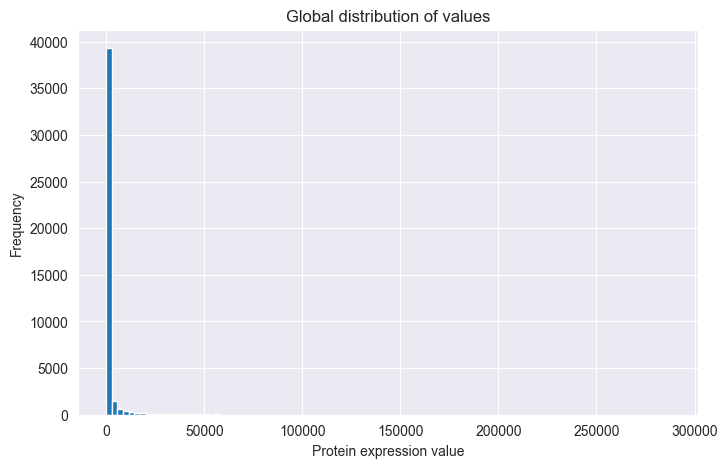


===== GLOBAL DISTRIBUTION SUMMARY =====
Skewness: 10.796
Min: 9.0
Max: 287408.0

Quantiles:
0.01       24.47
0.05       42.00
0.50      243.00
0.95     6548.00
0.99    31374.76
dtype: float64


{'skewness': np.float64(10.796327005456545),
 'min': np.float64(9.0),
 'max': np.float64(287408.0),
 'quantiles': 0.01       24.47
 0.05       42.00
 0.50      243.00
 0.95     6548.00
 0.99    31374.76
 dtype: float64}

In [4]:
plot_global_distribution(bl_dataset)

## Check changes after log transformation
Does skewness decrease? Does distribution become more symmetric? Are extreme values compressed?

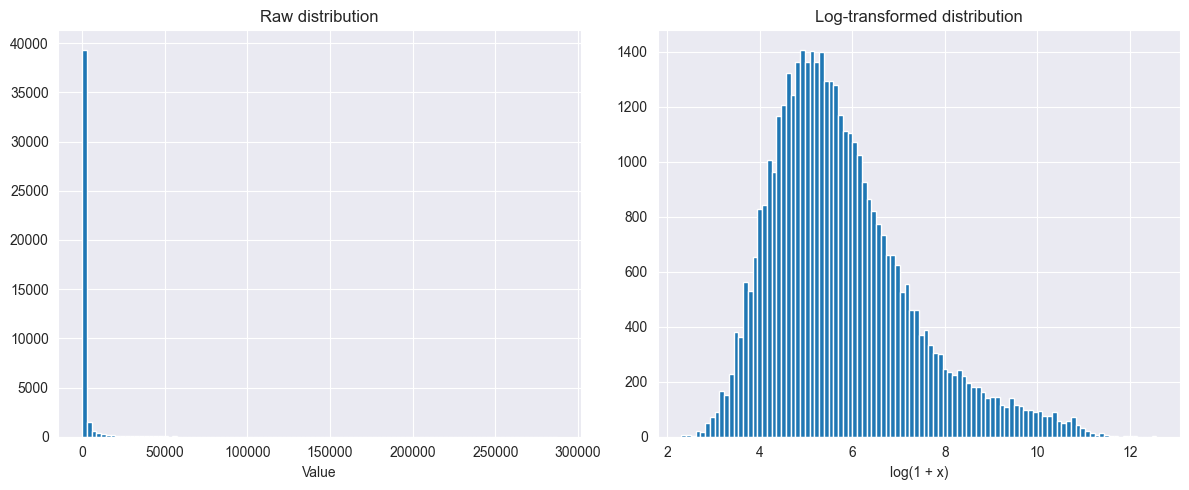


===== LOG TRANSFORM ASSESSMENT =====
Raw skewness: 10.796
Log skewness: 0.933
Raw range: 9.0 → 287408.0
Log range: 2.303 → 12.569


In [5]:
results = log_transform_assessment(bl_dataset)

## Protein-wide distribution assessment - check for normalisation at the individual protein level
Distribution plot for each protein, skewness for each protein, outlier summary for each protein

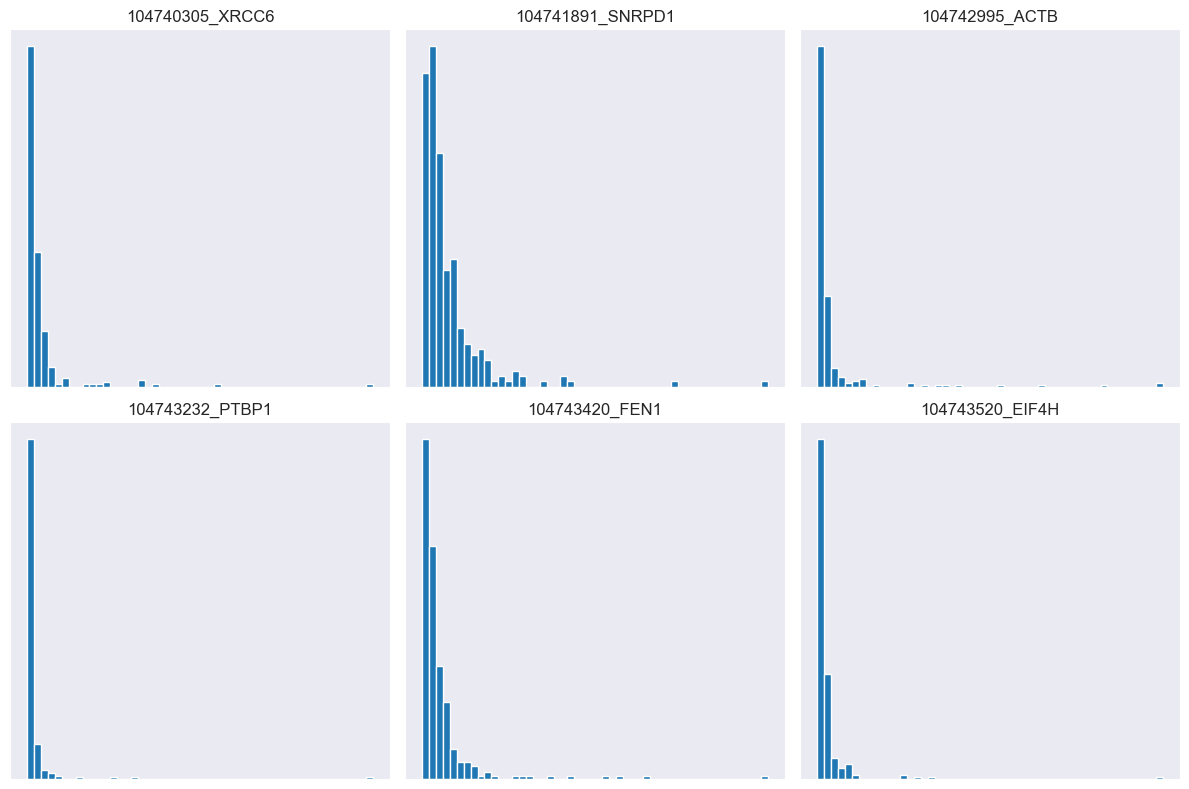

Index(['104740305_XRCC6', '104741891_SNRPD1', '104742995_ACTB',
       '104743232_PTBP1', '104743420_FEN1', '104743520_EIF4H', '104745245_TNC',
       '104745249_IGF1', '104745436_FN1', '104745443_IGFBP2', '104745679_SPP1',
       '104745733_VIM', '105481183_TRAF3IP3', '105481284_RPLP2',
       '105482048_ENO1', '105483201_NPM1', '105483601_CLU', '105484159_SP100',
       '105486564_DDX21', '105487234_DLST'],
      dtype='str')


In [10]:
# Plot protein distributions
plot_protein_distributions(bl_dataset)
print(bl_dataset.columns[:20])

In [16]:
# Check skewness for each protein
print("Number of proteins:", len(bl_dataset.columns))
skew = protein_skewness(bl_dataset)
skew = protein_skewness(bl_dataset)
print(skew.describe())
print("Proteins with skew > 1:", (skew > 1).sum())
print("Proteins with skew > 2:", (skew > 2).sum())
print("Total proteins:", len(skew))
print(skew.head(40))

Number of proteins: 163
count    163.000000
mean       6.569266
std        3.159638
min        1.801264
25%        4.497667
50%        5.833035
75%        7.612008
max       16.180487
dtype: float64
Proteins with skew > 1: 163
Proteins with skew > 2: 162
Total proteins: 163
APOH_1113180421_APOH          16.180487
105481284_RPLP2               16.142722
1043170594_EHD1               16.104710
1113172457_RPLP1              15.535749
1066865463_POU3F3             14.821557
1066859503_ELANE              14.767693
HNRNPA1_1066859223_HNRNPA1    14.053733
1066863255_IGFBP6             13.915251
1066862864_RBM39              13.904929
105510252_SRPR                13.313699
1066528529_HIST2H2AA3         13.014012
1066562962_MUC1               12.688745
104743232_PTBP1               12.510979
1066564880_NCF2               12.463306
1047888625_RPLP0              11.623257
159156372_TOP1                11.278709
1043171373_FGB                10.837619
1066527143_SH3KBP1            10.810582
10548

In [20]:
# Check outlier summary for each protein
outliers = protein_outlier_summary(bl_dataset)
print(outliers.head(40))

104740305_XRCC6       3
104741891_SNRPD1      3
104742995_ACTB        3
104743232_PTBP1       3
104743420_FEN1        3
104743520_EIF4H       3
104745245_TNC         3
104745249_IGF1        3
104745436_FN1         3
104745443_IGFBP2      3
104745679_SPP1        3
104745733_VIM         3
105481183_TRAF3IP3    3
105481284_RPLP2       3
105482048_ENO1        3
105483201_NPM1        3
105483601_CLU         3
105484159_SP100       3
105486564_DDX21       3
105487234_DLST        3
105489246_MS4A1       3
105507292_NONO        3
105507900_AARS        3
105507919_DDX5        3
105510087_SFPQ        3
105510131_SNRPN       3
105510252_SRPR        3
105511133_DNAJB1      3
159156372_TOP1        3
1043136644_IL6        3
1043136660_IL12B      3
1043136662_IL10       3
1043138774_MBP        3
1043140564_APOA4      3
1043140678_MX1        3
1043140754_CHD3       3
1043141227_SDC1       3
1043142674_FBXO44     3
1043142789_IL1B       3
1043143555_APOE       3
dtype: int64
